# quantEM EELS

Based on Stephanie Ribet's Notebook from , May 2026

Data from Yael Tsarfati & Karen Bustillo 

Acquired on the TEAM I -May 2026 session 
Monochromated dual EELS

pg3T2 FIB milled Lamella

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import quantem as em
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import sys, os, subprocess
import quantem as em
from scipy.ndimage import gaussian_filter
from typing import Optional, Tuple, Union
from rsciio.digitalmicrograph import file_reader

In [3]:
print("Python executable:", sys.executable)
print("Current working dir:", os.getcwd())
print("quantem imported from:", em.__file__)
print("git branch:", subprocess.check_output(["git", "branch", "--show-current"]).decode().strip())
print("git commit:", subprocess.check_output(["git", "rev-parse", "HEAD"]).decode().strip())

Python executable: /home/yaeltsa/quantem/.venv/bin/python
Current working dir: /home/yaeltsa/quantem
quantem imported from: /home/yaeltsa/quantem/src/quantem/__init__.py
git branch: spectroscopy
git commit: f5000135f9e6626ac419f09dde7b8bf843fef738


In [4]:
# Absolute path to your data (starts from root /)
data_path = Path(
    "/data/users/yaeltsa/SLAC/05-15-2026_STEM_ELLS_Mono_pg3T2/11_pg3T2_dual-EELS_9meV_dispersion_0pt05s_pixel-dwell_54x88_scan_0eV_low_520eV_high_100perc_live-time_1s_view-time_7pt5nm_stepsize_top_layer_O_Kedge/STEM SI.dm4"
)
labels = ["O K-edge"]

print(f"Checking: {data_path}")
print(f"Exists: {data_path.exists()}")

# This should work regardless of where your notebook is located
eels_ll = em.io.read_3d_spectroscopy(
    str(data_path), file_type="digitalmicrograph", data_type="EELS"
)
eels_hl = em.io.read_3d_spectroscopy(
    str(data_path), file_type="digitalmicrograph", data_type="EELS", dataset_index=3
)

# For the sacn images
all_data = file_reader(str(data_path))

Checking: /data/users/yaeltsa/SLAC/05-15-2026_STEM_ELLS_Mono_pg3T2/11_pg3T2_dual-EELS_9meV_dispersion_0pt05s_pixel-dwell_54x88_scan_0eV_low_520eV_high_100perc_live-time_1s_view-time_7pt5nm_stepsize_top_layer_O_Kedge/STEM SI.dm4
Exists: True
File contains 4 dataset(s) and 2 3D dataset(s) at indices 2, 3. Using dataset 2 with shape (2764, 88, 54)


In [5]:
print("Shape of eels_ll:", eels_ll.shape)
print("Shape of eels_hl:", eels_hl.shape)

Shape of eels_ll: (88, 54, 2764)
Shape of eels_hl: (88, 54, 2764)


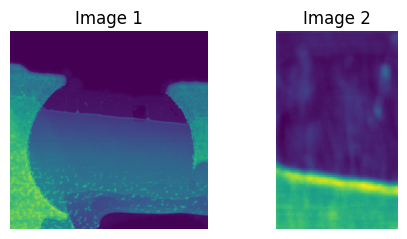

In [6]:
image_data1 = all_data[0]["data"]
image_data2 = all_data[1]["data"]
# Create subplots for side-by-side layout
fig, axes = plt.subplots(1, 2, figsize=(5, 2.5))  # 1 row, 2 columns

# Plotting the first image
axes[0].imshow(image_data1, cmap="viridis")  # Adjust the colormap as necessary
axes[0].set_title("Image 1")
axes[0].axis("off")  # Optional: Turn off axis

# Plotting the second image
axes[1].imshow(image_data2, cmap="viridis")  # Adjust the colormap as necessary
axes[1].set_title("Image 2")
axes[1].axis("off")  # Optional: Turn off axis

# Adjust layout
plt.tight_layout()
plt.show()

In [7]:
# # Check what's in the file
# print(f"Number of datasets: {len(all_data)}")

# for i, dataset in enumerate(all_data):
#     print(f"\nDataset {i}:")
#     print(f"  Shape: {dataset['data'].shape}")
#     print(f"  Data type: {dataset['data'].dtype}")
#     if 'axes' in dataset:
#         print(f"  Axes: {[ax.get('name', 'unnamed') for ax in dataset['axes']]}")
#     if 'metadata' in dataset:
#         print(f"  Metadata keys: {list(dataset['metadata'].keys())[:5]}...")  # first 5 keys

# Index	Shape	Type	What It Is
# 0	(512, 512)	uint32	STEM survey image (high-res)
# 1	(26, 70)	float32	HAADF/ADF image from SI
# 2	(3456, 26, 70)	float32	EELS datacube (raw or processed)
# 3	(3456, 26, 70)	float32	EELS datacube (duplicate or different processing)

(<Figure size 1200x400 with 3 Axes>,
 (<Axes: title={'center': 'Integrated Intensity Map'}>,
  <Axes: title={'center': 'Spectrum from ROI [0:88, 0:54]'}, xlabel='Energy (eV)', ylabel='Intensity'>))

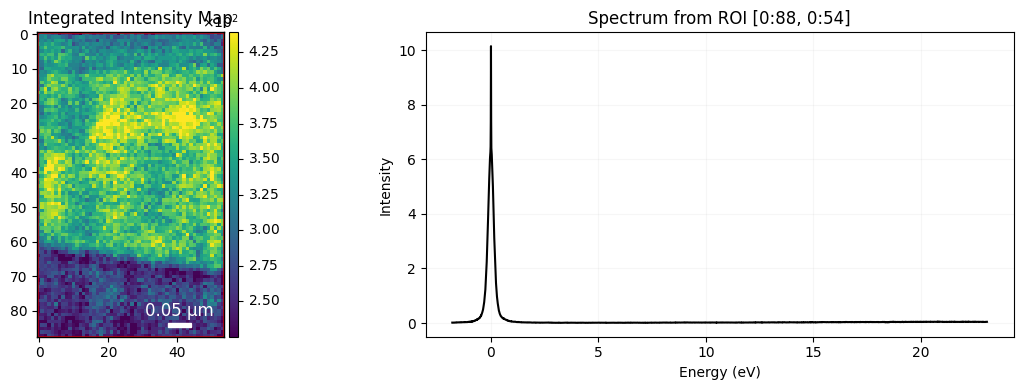

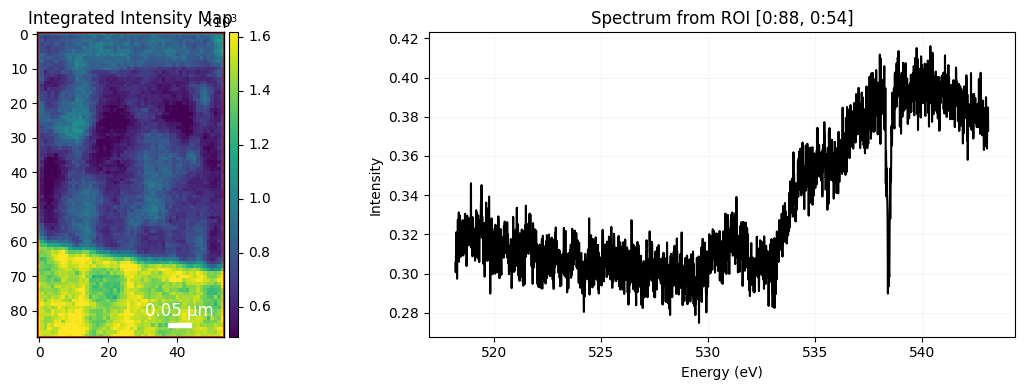

In [8]:
eels_ll.show_mean_spectrum()
eels_hl.show_mean_spectrum()


Calculating thickness map from low-loss data...
ZLP window: -5 to 5 eV → indices (np.int64(0), np.int64(755))
Total window: -5 to 50 eV → indices (np.int64(0), np.int64(2763))
QuantEM: Calculating thickness for 3D dataset...


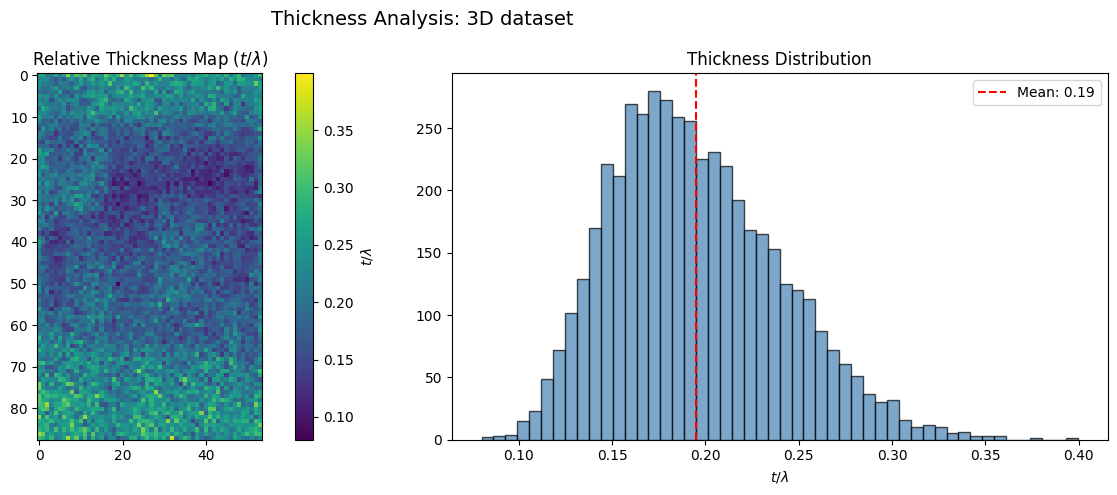


Thickness map statistics:
  Shape: (88, 54)
  Min: 0.080 t/λ
  Max: 0.399 t/λ
  Mean: 0.195 t/λ
  Median: 0.189 t/λ
  Std dev: 0.045 t/λ


In [9]:
# ===== CALCULATE THICKNESS MAP =====
print("\nCalculating thickness map from low-loss data...")

# First, determine the indices for ZLP and total integration windows
# You need to convert energy ranges to index ranges

# Define energy windows
zlp_energy_range = (-5, 5)  # Energy range for ZLP (eV)
total_energy_range = (-5, 50)  # Total integration range (eV)

# Convert energy ranges to indices
energy_axis = eels_ll.energy_axis

# Find indices for ZLP window
zlp_mask = (energy_axis >= zlp_energy_range[0]) & (energy_axis <= zlp_energy_range[1])
zlp_indices = np.where(zlp_mask)[0]
zlp_idx = (zlp_indices[0], zlp_indices[-1])

# Find indices for total window
total_mask = (energy_axis >= total_energy_range[0]) & (energy_axis <= total_energy_range[1])
total_indices = np.where(total_mask)[0]
total_idx = (total_indices[0], total_indices[-1])

print(f"ZLP window: {zlp_energy_range[0]} to {zlp_energy_range[1]} eV → indices {zlp_idx}")
print(f"Total window: {total_energy_range[0]} to {total_energy_range[1]} eV → indices {total_idx}")

# Create window_params dictionary with the correct structure
window_params = {
    "zlp_idx": zlp_idx,  # (start_index, end_index) for ZLP
    "total_idx": total_idx,  # (start_index, end_index) for total
}

# Now calculate thickness
thickness_map = eels_ll.calculate_thickness_log_ratio(
    window_params=window_params,
    plot=True,  # Set to True to see the windows being used
)

print(f"\nThickness map statistics:")
print(f"  Shape: {thickness_map.shape}")
print(f"  Min: {thickness_map.min():.3f} t/λ")
print(f"  Max: {thickness_map.max():.3f} t/λ")
print(f"  Mean: {thickness_map.mean():.3f} t/λ")
print(f"  Median: {np.median(thickness_map):.3f} t/λ")
print(f"  Std dev: {thickness_map.std():.3f} t/λ")

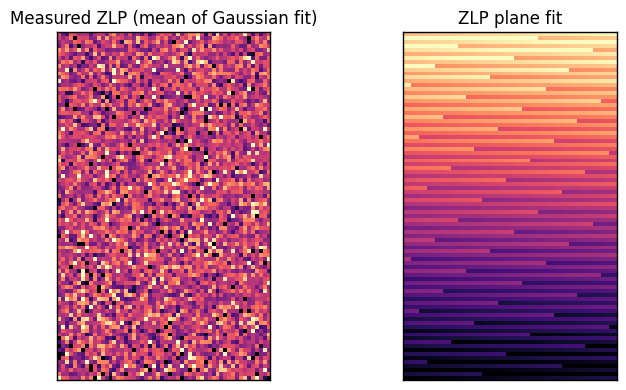

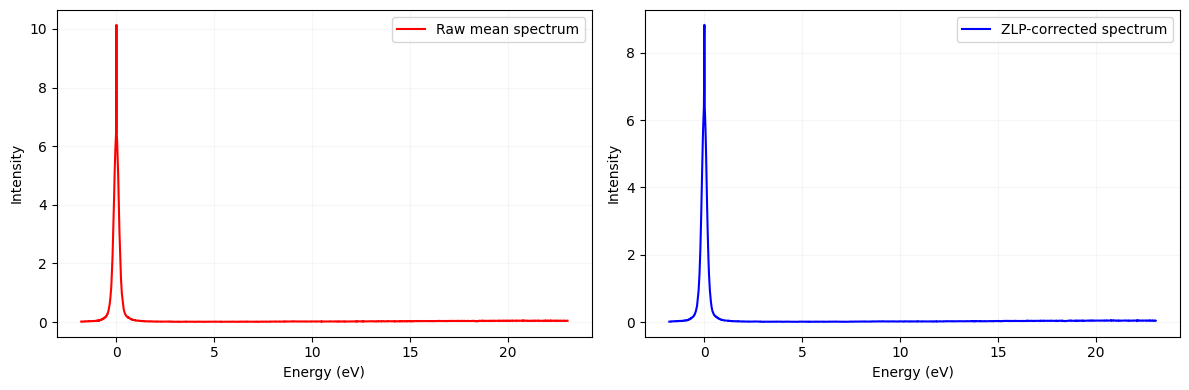

In [10]:
eels_ll, zlp_shifts = eels_ll.apply_zlp_correction(
    measure_offset=True, fit_to_plane=True, return_3d_dataset=True, return_shifts=True
)

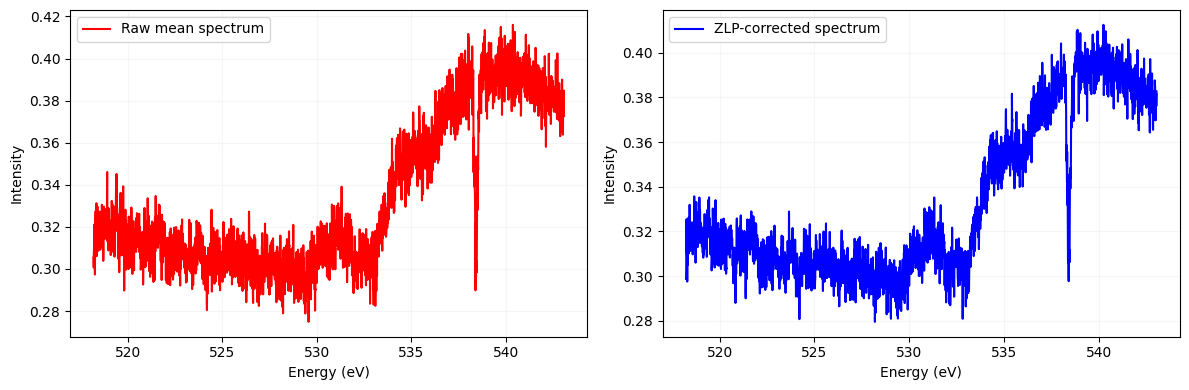

In [11]:
eels_hl = eels_hl.apply_zlp_correction(
    zlp_shifts_array=zlp_shifts,  # Use measured shifts
    measure_offset=False,
    return_3d_dataset=True,
)

In [12]:
# Look for anything containing 'shift' or 'offset'
# print([attr for attr in dir(eels_ll) if 'shift' in attr or 'offset' in attr])
# ll_zlpshifts.max()

(<Figure size 1200x400 with 3 Axes>,
 (<Axes: title={'center': 'Integrated Intensity Map'}>,
  <Axes: title={'center': 'Spectrum from ROI [0:88, 0:54]'}, xlabel='Energy (eV)', ylabel='Intensity'>))

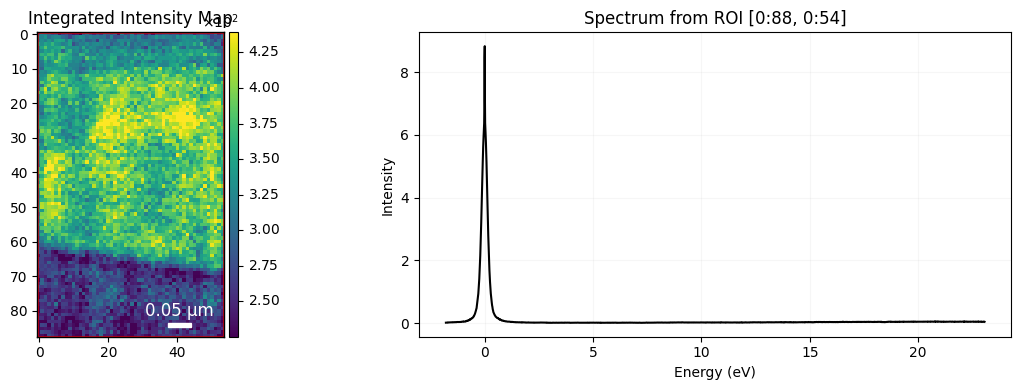

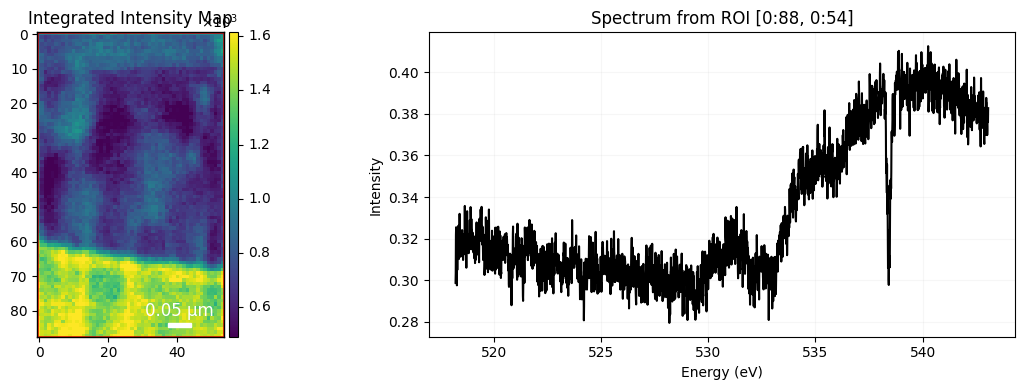

In [13]:
eels_ll.show_mean_spectrum()
eels_hl.show_mean_spectrum()

In [14]:
eels_hl.bin(1, axes=0, modify_in_place=True)
# eels_hl.show_mean_spectrum()

In [15]:
## ---------Background substruction---------
print(f"Energy range: {eels_hl.energy_axis[0]:.1f} to {eels_hl.energy_axis[-1]:.1f} eV")
print(f"Shape: {eels_hl.shape}")

Energy range: 518.2 to 543.1 eV
Shape: (88, 54, 2761)


Auto-detected pre-edge: 518.2 - 527.0 eV
Pre-edge region: 8.8 eV (976 data points)
✓ Fit method: Polynomial (degree 2)


/home/yaeltsa/quantem/src/quantem/spectroscopy/dataset3deels.py:258: UserWarning: Limited pre-edge region (8.8 eV). Background fit may be unreliable. Consider method='linear' for stability.
  warnings.warn(


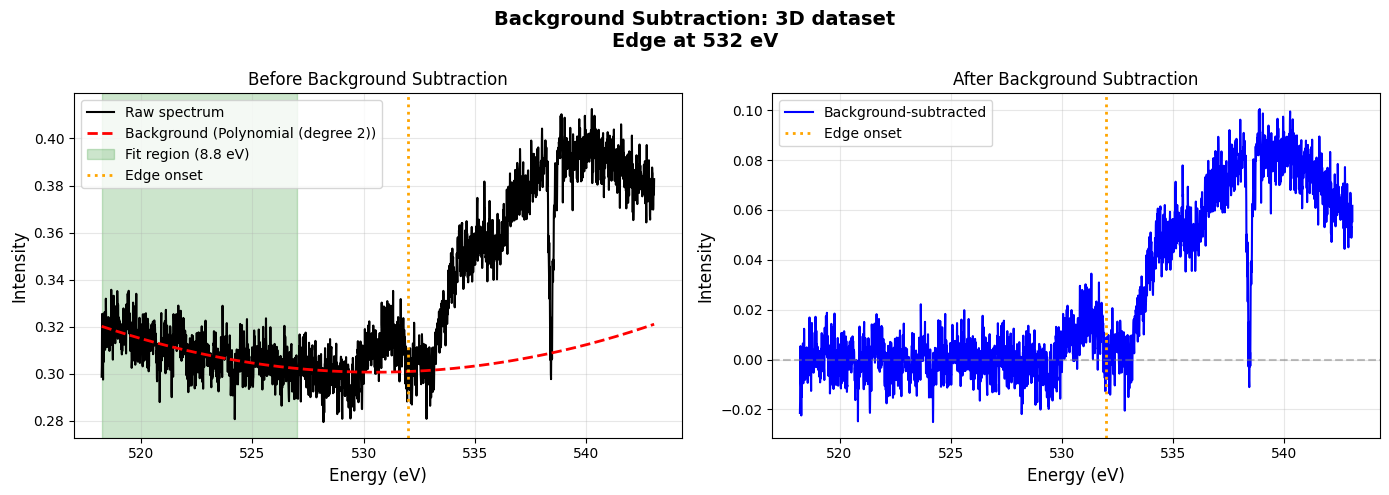

✓ Created background-subtracted dataset: (88, 54, 2761)


In [16]:
# Your O K-edge case (518-543 eV range, edge at 532 eV)
eels_hl_S = eels_hl.subtract_background_limited_preedge(
    target_edge=532, method="polynomial", polynomial_degree=2, show=True
)

Using specified pre-edge: 519.0 - 527.0 eV
Pre-edge region: 8.0 eV (889 data points)
✓ Fit method: Linear: y = -2.00e-03*E + 1.35e+00


/home/yaeltsa/quantem/src/quantem/spectroscopy/dataset3deels.py:258: UserWarning: Limited pre-edge region (8.0 eV). Background fit may be unreliable. Consider method='linear' for stability.
  warnings.warn(


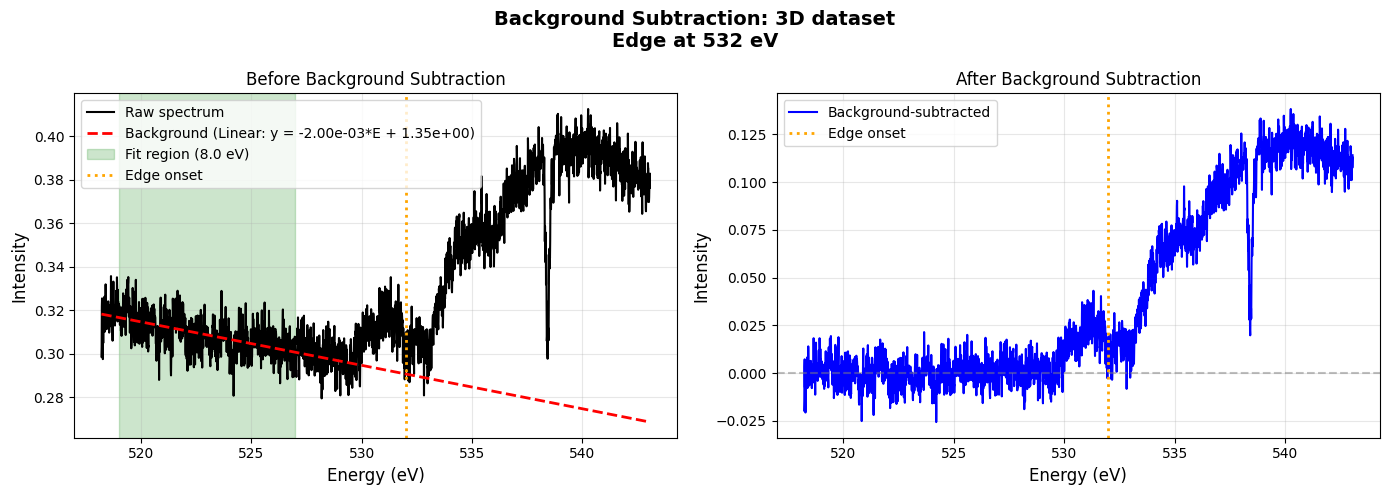

✓ Created background-subtracted dataset: (88, 54, 2761)


In [17]:
# Or with explicit pre-edge window
eels_hl_SS = eels_hl.subtract_background_limited_preedge(
    target_edge=532,
    pre_edge_range=(519, 527),  # 8 eV window
    method="linear",
    show=True,
)

(<Figure size 1200x400 with 3 Axes>,
 (<Axes: title={'center': 'Integrated Intensity Map'}>,
  <Axes: title={'center': 'Spectrum from ROI [0:88, 0:54]'}, xlabel='Energy (eV)', ylabel='Intensity'>))

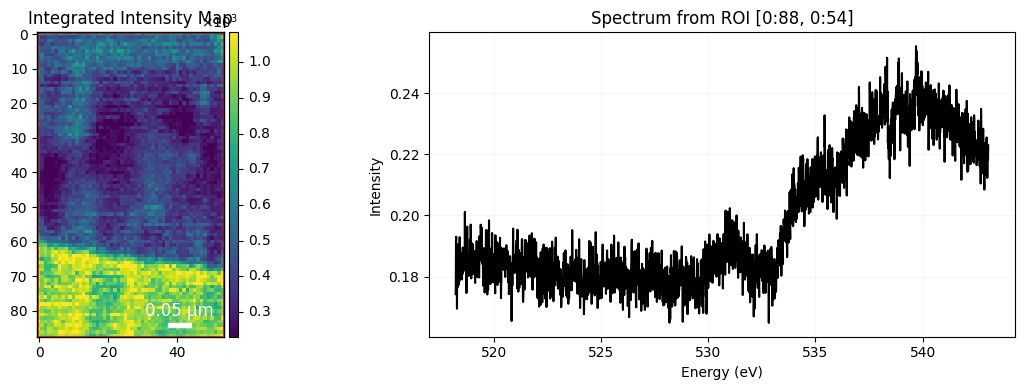

In [18]:
eels_hl_S.show_mean_spectrum()


3. Chemical mapping:


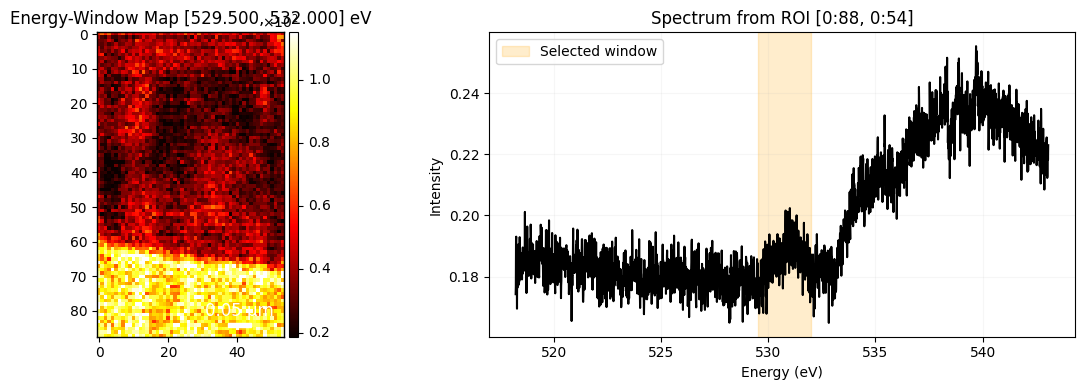

<Figure size 640x480 with 0 Axes>

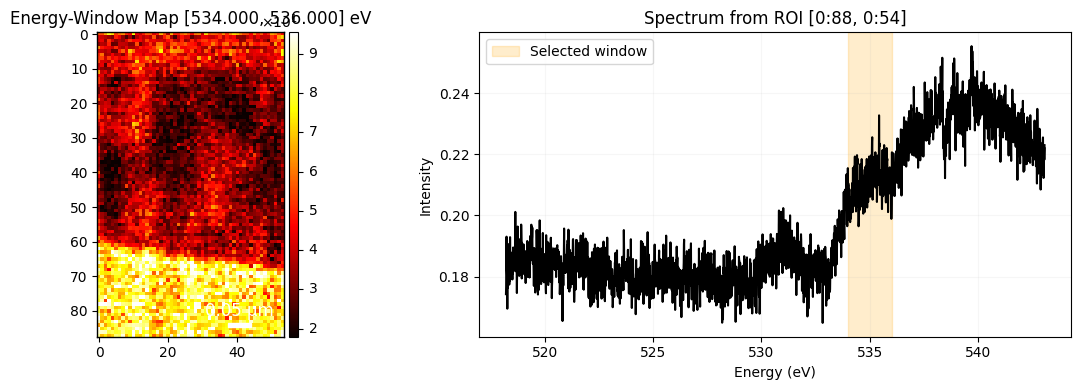

<Figure size 640x480 with 0 Axes>

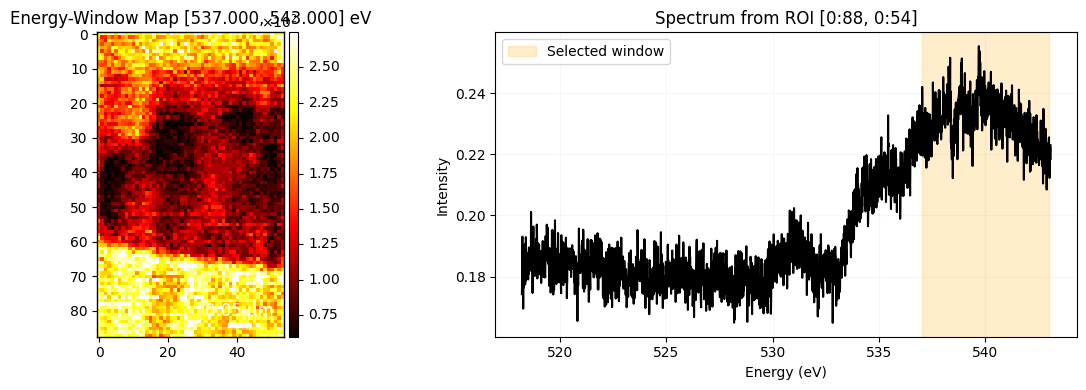


✓ Analysis complete!


<Figure size 640x480 with 0 Axes>

In [19]:
# Now create maps
print("\n3. Chemical mapping:")

fig1, _, map_1 = eels_hl_S.show_energy_window_map(energy_window=[529.5, 532], cmap="hot")
plt.suptitle("(229.5, 233] eV)")

fig2, _, map_2 = eels_hl_S.show_energy_window_map(energy_window=[534, 536], cmap="hot")
plt.suptitle("([534, 543] eV)")

fig3, _, map_3 = eels_hl_S.show_energy_window_map(energy_window=[537, 543], cmap="hot")
plt.suptitle("([534, 543] eV)")


# # Ratio map
# ratio_map = map_prepeak / (map_mainpeak + 1e-10)
# from quantem.core.visualization import show_2d
# show_2d(ratio_map, title="", cmap='RdBu_r', cbar=True)

# Save

# # Ratio map
# ratio_map = map_1 /(map_4 + 1e-10)
# from quantem.core.visualization import show_2d
# show_2d(ratio_map, title="", cmap='RdBu_r', cbar=True)


print("\n✓ Analysis complete!")


3. Chemical mapping:


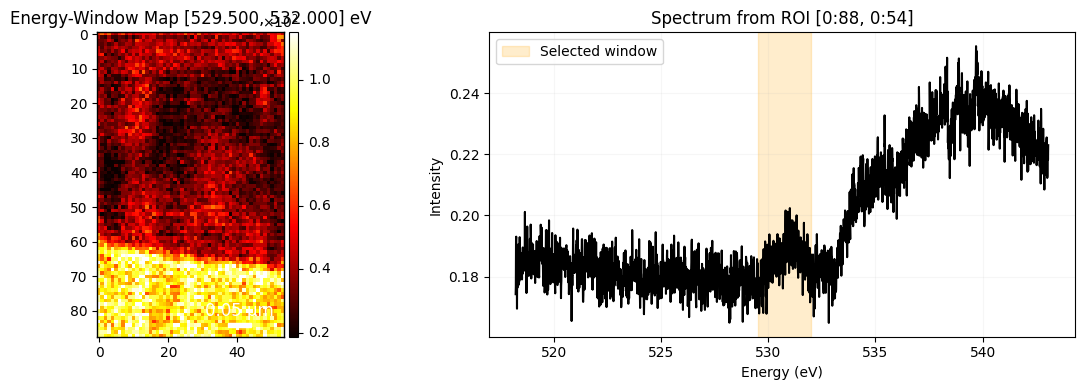

<Figure size 640x480 with 0 Axes>

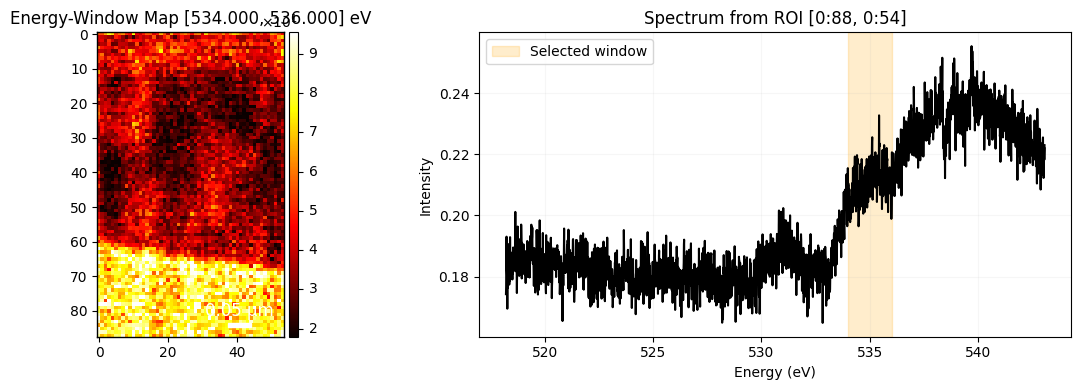

<Figure size 640x480 with 0 Axes>

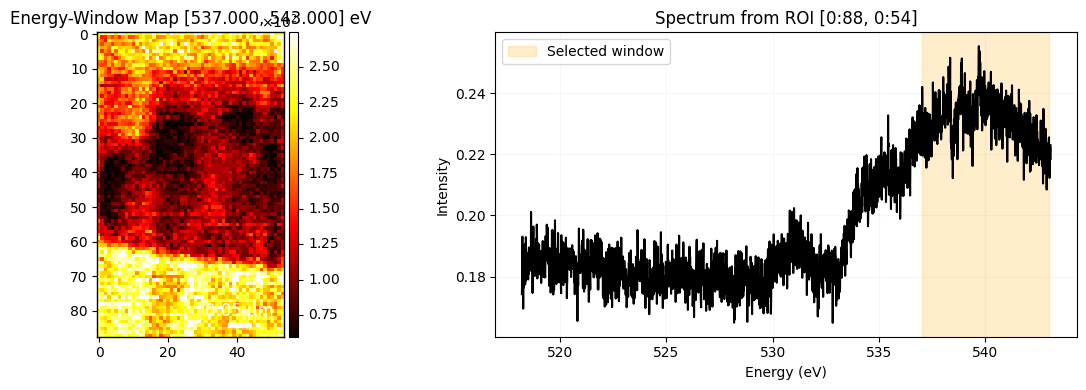


✓ Analysis complete!


<Figure size 640x480 with 0 Axes>

In [ ]:
# Now create maps
print("\n3. Chemical mapping:")

fig1, _, map_1 = eels_hl_S.show_energy_window_map(energy_window=[529.5, 532], cmap="hot")
plt.suptitle("(229.5, 233] eV)")

fig2, _, map_2 = eels_hl_S.show_energy_window_map(energy_window=[534, 536], cmap="hot")
plt.suptitle("([534, 543] eV)")

fig3, _, map_3 = eels_hl_S.show_energy_window_map(energy_window=[537, 543], cmap="hot")
plt.suptitle("([534, 543] eV)")


# # Ratio map
# ratio_map = map_prepeak / (map_mainpeak + 1e-10)
# from quantem.core.visualization import show_2d
# show_2d(ratio_map, title="", cmap='RdBu_r', cbar=True)

# Save

# # Ratio map
# ratio_map = map_1 /(map_4 + 1e-10)
# from quantem.core.visualization import show_2d
# show_2d(ratio_map, title="", cmap='RdBu_r', cbar=True)


print("\n✓ Analysis complete!")

(<Figure size 800x400 with 2 Axes>,
 array([<Axes: title={'center': 'DF'}>,
        <Axes: title={'center': '532eV map'}>], dtype=object))

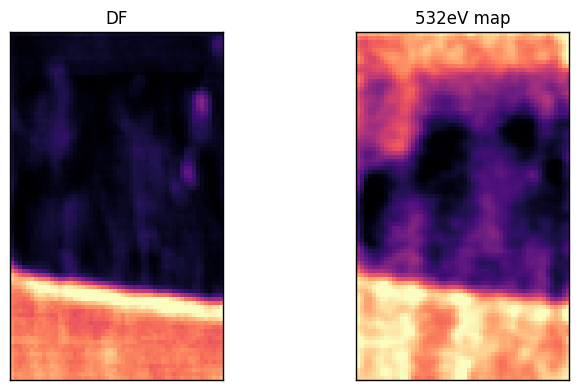

In [29]:
em.visualization.show_2d(
    [all_data[1]["data"], gaussian_filter(map_3, 1)],
    title=["DF", "532eV map"],
    cmap="magma",
)

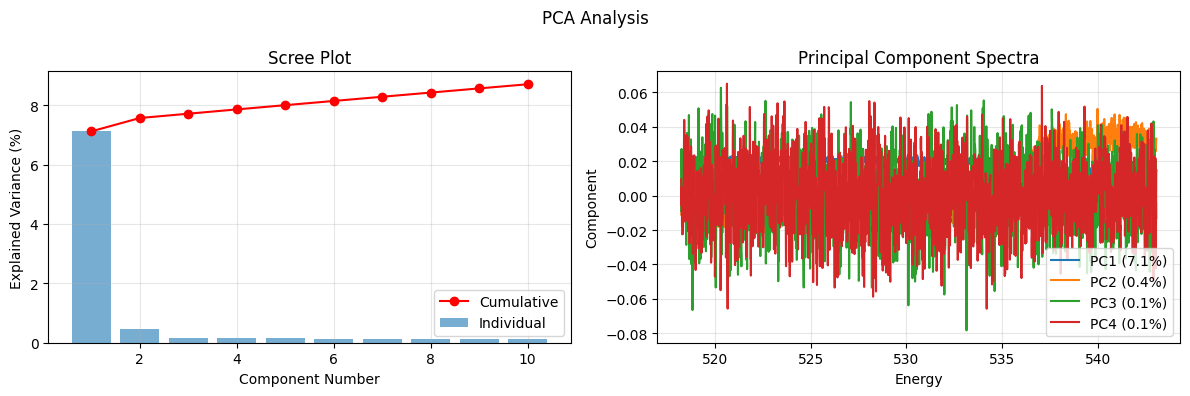

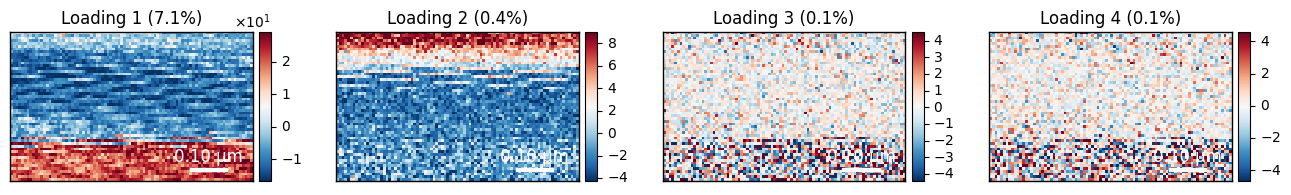

In [21]:
eels_hl_S.perform_pca()

In [25]:
# Extract the numpy arrays
haadf_data = (all_data[1]["data"],)  # Your darkfield image
loading_data = eels_hl_S.get_decomposition_loadings().inav[0].data  # Component 0

# Create overlay
fig, ax = plt.subplots(figsize=(10, 8))

# Plot darkfield as base
ax.imshow(haadf_data, cmap="gray", origin="lower")

# Overlay loading with transparency
im = ax.imshow(loading_data, cmap="RdBu_r", alpha=0.5, origin="lower")

plt.colorbar(im, ax=ax, label="PCA Loading Component 0")
ax.set_title("PCA Loading Overlaid on HAADF")
ax.axis("off")
plt.tight_layout()
plt.show()

AttributeError: 'Dataset3deels' object has no attribute 'get_decomposition_loadings'